In [1]:
%reload_ext autoreload
%autoreload 2


In [2]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

plt.style.use("../dmri/utils/pyloric_black.mplstyle")

# Ignore font warnings from matplotlib
import warnings
warnings.filterwarnings("ignore")
# Ignore missing font warnings from seaborn
warnings.filterwarnings("ignore", module="matplotlib.font_manager")


sim_type = Ball3StickSharedDiffusivity
ball_stick = sim_type.from_theta(np.random.randn(sim_type.theta_dim))

Duplicate key in file '../dmri/utils/pyloric_black.mplstyle', line 65 ('savefig.facecolor    : black       # Ensures black background when saving')


In [3]:
from dmri.simulators.acquisition_scheme import acquisition_scheme, random_hcp_acquisition


@jax.jit
def simulator(rng):
    rng0, rng1, rng2, rng3, rng4, rng5 = jax.random.split(rng, 6)
    acq = random_hcp_acquisition(rng)


    theta = jax.random.normal(rng1, shape=(sim_type.theta_dim,))
    rng_p, rng_m = jax.random.split(rng2)
    p_mask = jax.random.beta(rng_p, a=1, b=1, shape=(1,))
    model_mask = jax.random.bernoulli(rng_m, p=p_mask, shape=(len(sim_type.model_types)))
    # This needs to have only one entry
    model_noise_idx = jax.random.randint(rng4, minval=0, maxval=len(sim_type.noise_types), shape=(1,))
    model_noise_mask = jnp.zeros(len(sim_type.noise_types), dtype=jnp.bool)
    model_noise_mask = model_noise_mask.at[model_noise_idx].set(True)
    model_mask = jnp.concatenate([model_mask, model_noise_mask], axis=-1)
    ball_stick = sim_type.from_theta(theta, model_mask=model_mask)

    x_o = ball_stick.signal(acq, rng=rng5)
    return p_mask, model_mask, theta, x_o, acq


In [4]:
p_mask,masks, theta, x_o, acq= jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

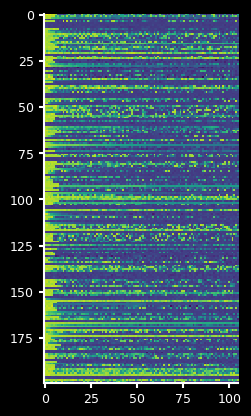

In [5]:
import matplotlib.pyplot as plt
plt.imshow(x_o)

In [6]:
from dmri.nn.dmri_reconstruction_model import DMRIInferenceModel, DMRIInferenceModelConfig, DMRIInferenceModelConfigMaskPriorAmortized, DMRIInferenceModelConfigMaskPriorAmortizedPP
from dmri.nn.tokenizer import DMRITokenizerPP

cfg = DMRIInferenceModelConfigMaskPriorAmortized(sim_type, use_attention_mask=True)
model = DMRIInferenceModel(cfg, nnx.Rngs(1))

In [7]:
model(masks, theta, x_o, acq.bvals, acq.bvecs, p_mask)

(0, 1, 2, 3, 4)


(Array([[-0.947, -0.475,  0.995,  0.157,  0.104],
        [-1.24 , -0.875,  0.838, -0.164, -1.66 ],
        [-0.95 , -0.696,  0.723, -1.226,  0.089],
        [-0.702, -0.356, -0.438, -0.488, -0.522],
        [-1.043, -0.528,  0.622,  0.114, -1.464],
        [-0.646, -0.316, -0.384, -0.427, -0.455],
        [-0.665, -0.244, -0.307, -0.348, -0.377],
        [-0.889, -0.549, -0.63 , -0.679, -0.712],
        [-1.008, -0.578, -0.597, -1.626, -0.611],
        [-0.752, -0.287, -0.334, -0.458, -0.533],
        [-0.615, -0.343,  0.993,  0.254, -1.134],
        [-1.193, -0.795, -0.866, -1.806, -0.803],
        [-1.117, -0.733,  0.234, -0.096, -0.125],
        [-1.064, -0.526,  0.587,  0.106, -1.45 ],
        [-1.119, -0.66 , -0.606, -1.603, -0.613],
        [-0.872, -0.437, -0.5  , -0.537, -1.433],
        [-0.433, -0.212,  1.149, -0.576, -0.767],
        [-0.675, -0.457,  1.057, -1.03 , -1.259],
        [-1.174, -0.744, -0.796, -1.542, -1.78 ],
        [-1.142, -0.702,  0.852, -0.115, -0.19 ],


In [51]:
import optax

#scheduler = optax.cosine_onecycle_schedule(100*500, 5e-4)
optimizer = optax.chain(optax.adaptive_grad_clip(50.),  optax.adamw(1e-3))

params = nnx.state(model, nnx.Param)
opt_state = optimizer.init(params)


In [9]:
from dmri.train.dataloader import StreamDataLoader

dataloader = StreamDataLoader(simulator, batch_size=2048, num_producers=4)

In [10]:
dataloader.queue_size()

0

In [11]:
datastream = iter(dataloader)

In [12]:

def loss_fn(params, data, rng):
    nnx.update(model, params)
    p_mask, model_mask, thetas,  xs, bvals, bvecs = data
    losses =  model.loss_fn(rng,model_mask=model_mask, theta=thetas, x=xs,bvals=bvals, bvecs=bvecs, mask_prior=p_mask, use_loss_mask=False)
    loss0 = losses[0]
    loss1 = losses[1]
    return 0.001 * loss0 + 0.999*loss1


@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [52]:
data_stream = iter(dataloader)
for i in range(20):
    key = jax.random.PRNGKey(i)
    l = 0
    for j in range(500):
        key, subkey2 = jax.random.split(key, 2)
        x = next(data_stream)
        p_mask_batch, masks_batch, thetas_batch, x_os_batch, acq= x
        bvals_batch, bvecs_batch = acq.bvals, acq.bvecs
        params, opt_state, loss = update(params, opt_state, (p_mask_batch,masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch), subkey2)
        l += loss
    print(l/500)

2.487234
2.4747958
2.470177
2.4644516
2.4603412
2.458829
2.4577885
2.4524682
2.4493628
2.446773
2.4443471
2.4443808
2.444278
2.4414186
2.437803
2.4371552
2.432524
2.4338284


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x155551a6d650>>
Traceback (most recent call last):
  File "/home/macke/mgloeckler90/miniconda3/envs/dipy/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


2.4310296
2.4306784


In [53]:
nnx.update(model, params)

In [54]:
batch_simulator = jax.jit(jax.vmap(simulator))
p_mask, masks, thetas, x_os, acq = batch_simulator(jax.random.split(jax.random.key(0), 100))

In [55]:
masks.sum(0)

Array([ 44,  44,  38,  48, 100], dtype=int32)

In [ ]:
#idx = 2
idx = 200
while not (masks[idx] == jnp.array([True,True,True, True, True])).all():
    idx += 1
masks[idx]

In [ ]:
model.tokenizer.embed_cfgs(masks[idx], alpha_prior=sim_type.fraction_prior)

(0, 1, 2, 3, 4)


Array([[-1.345, -0.883,  0.391,  0.489,  0.639,  0.817,  0.469, -0.327,
        -0.172, -1.068, -1.395,  0.964, -0.676,  0.861, -1.193,  0.595,
        -0.885,  0.621, -1.401, -0.135,  0.872, -1.343, -0.301,  1.019,
         1.229, -1.359,  0.258, -1.67 ,  0.983,  0.941, -0.563, -0.436,
        -0.254,  0.161,  1.141,  1.686, -0.679, -1.532,  1.645,  0.26 ,
        -1.068, -0.232,  0.694,  1.511, -0.221, -0.068, -0.455,  0.384,
        -0.107,  0.115,  0.117,  0.627, -1.045,  0.561,  0.655,  1.224,
        -0.16 , -1.844,  1.203, -1.859,  1.185, -1.471,  0.252,  1.142],
       [-0.382,  0.359, -0.262,  0.082,  0.085, -0.16 , -0.091, -0.18 ,
         0.104,  0.307, -0.284, -0.109,  0.053,  0.003,  0.17 ,  0.433,
        -0.013, -0.569, -0.119,  0.242, -0.083,  0.306,  0.057, -0.441,
        -0.208, -0.082, -0.113,  0.22 , -0.07 , -0.074,  0.193, -0.041,
        -0.122,  0.04 ,  0.248,  0.245, -0.211,  0.191,  0.187,  0.351,
        -0.149,  0.282,  0.243,  0.323,  0.044, -0.321,  0.026,

In [ ]:
x_os[idx]

Array([0.989, 0.952, 1.011, 1.018, 1.021, 0.814, 0.832, 0.828, 0.804,
       0.813, 0.798, 0.854, 0.826, 0.822, 0.806, 0.775, 0.809, 0.823,
       0.824, 0.806, 0.744, 0.784, 0.814, 0.773, 0.8  , 0.811, 0.766,
       0.89 , 0.826, 0.815, 0.815, 0.782, 0.826, 0.852, 0.779, 0.771,
       0.767, 0.811, 0.778, 0.782, 0.846, 0.774, 0.831, 0.805, 0.785,
       0.78 , 0.795, 0.796, 0.808, 0.799, 0.766, 0.846, 0.851, 0.811,
       0.818, 0.65 , 0.664, 0.595, 0.648, 0.691, 0.649, 0.679, 0.635,
       0.613, 0.679, 0.639, 0.641, 0.705, 0.732, 0.606, 0.712, 0.582,
       0.67 , 0.569, 0.587, 0.614, 0.66 , 0.65 , 0.584, 0.594, 0.631,
       0.569, 0.544, 0.631, 0.612, 0.683, 0.588, 0.674, 0.641, 0.665,
       0.648, 0.648, 0.717, 0.681, 0.612, 0.643, 0.695, 0.624, 0.597,
       0.566, 0.6  , 0.699, 0.672, 0.711, 0.644], dtype=float32)

In [44]:
mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 128), acq.bvals[idx], acq.bvecs[idx], x_os[idx], jnp.array([0.5]))

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

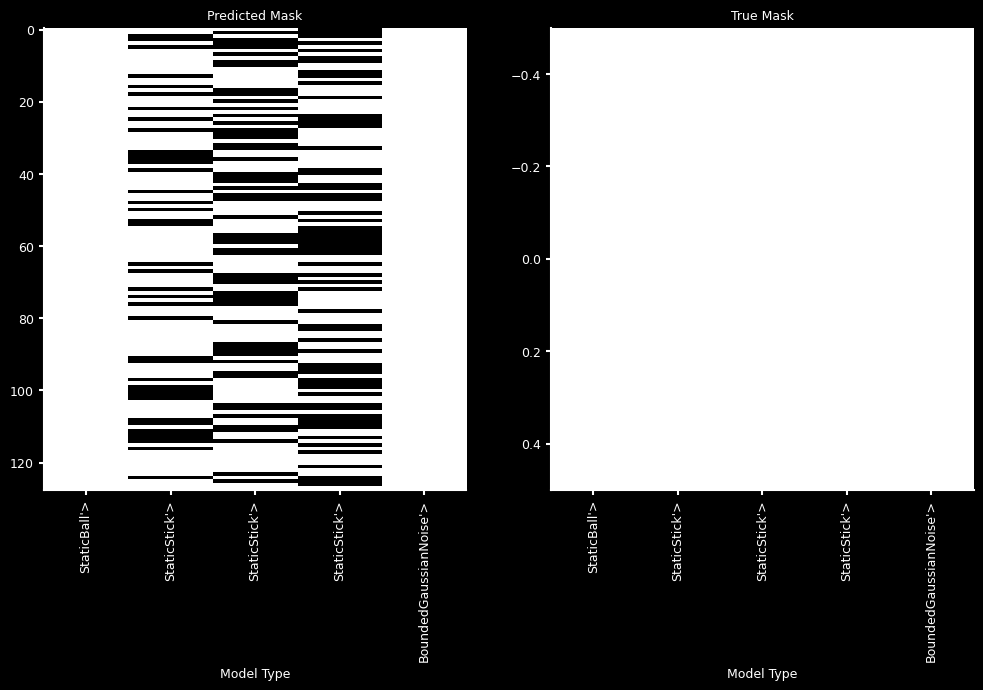

In [ ]:
plt.figure(figsize=(12, 6))

# Plot predicted mask
plt.subplot(1, 2, 1)
plt.imshow(mask, aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('Predicted Mask')
plt.xlabel('Model Type')
plt.xticks(range(len(sim_type.model_types) + len(sim_type.noise_types)), [str(m).split(".")[-1] for m in sim_type.model_types] + [str(m).split(".")[-1] for m in sim_type.noise_types], rotation=90)

# Plot true mask
mask_true = masks[idx]
plt.subplot(1, 2, 2)
plt.imshow(mask_true[None], aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('True Mask')
plt.xlabel('Model Type')
plt.xticks(range(len(sim_type.model_types) + len(sim_type.noise_types)), [str(m).split(".")[-1] for m in sim_type.model_types] + [str(m).split(".")[-1] for m in sim_type.noise_types], rotation=90)

plt.show()

In [46]:
from functools import partial

In [ ]:
thetas_post = jax.vmap(partial(model.sample_theta, num_steps=256, max_noise=80), in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 4096), acq.bvals[idx], acq.bvecs[idx], x_os[idx],masks[idx])

(0, 1, 2, 3, 4)


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

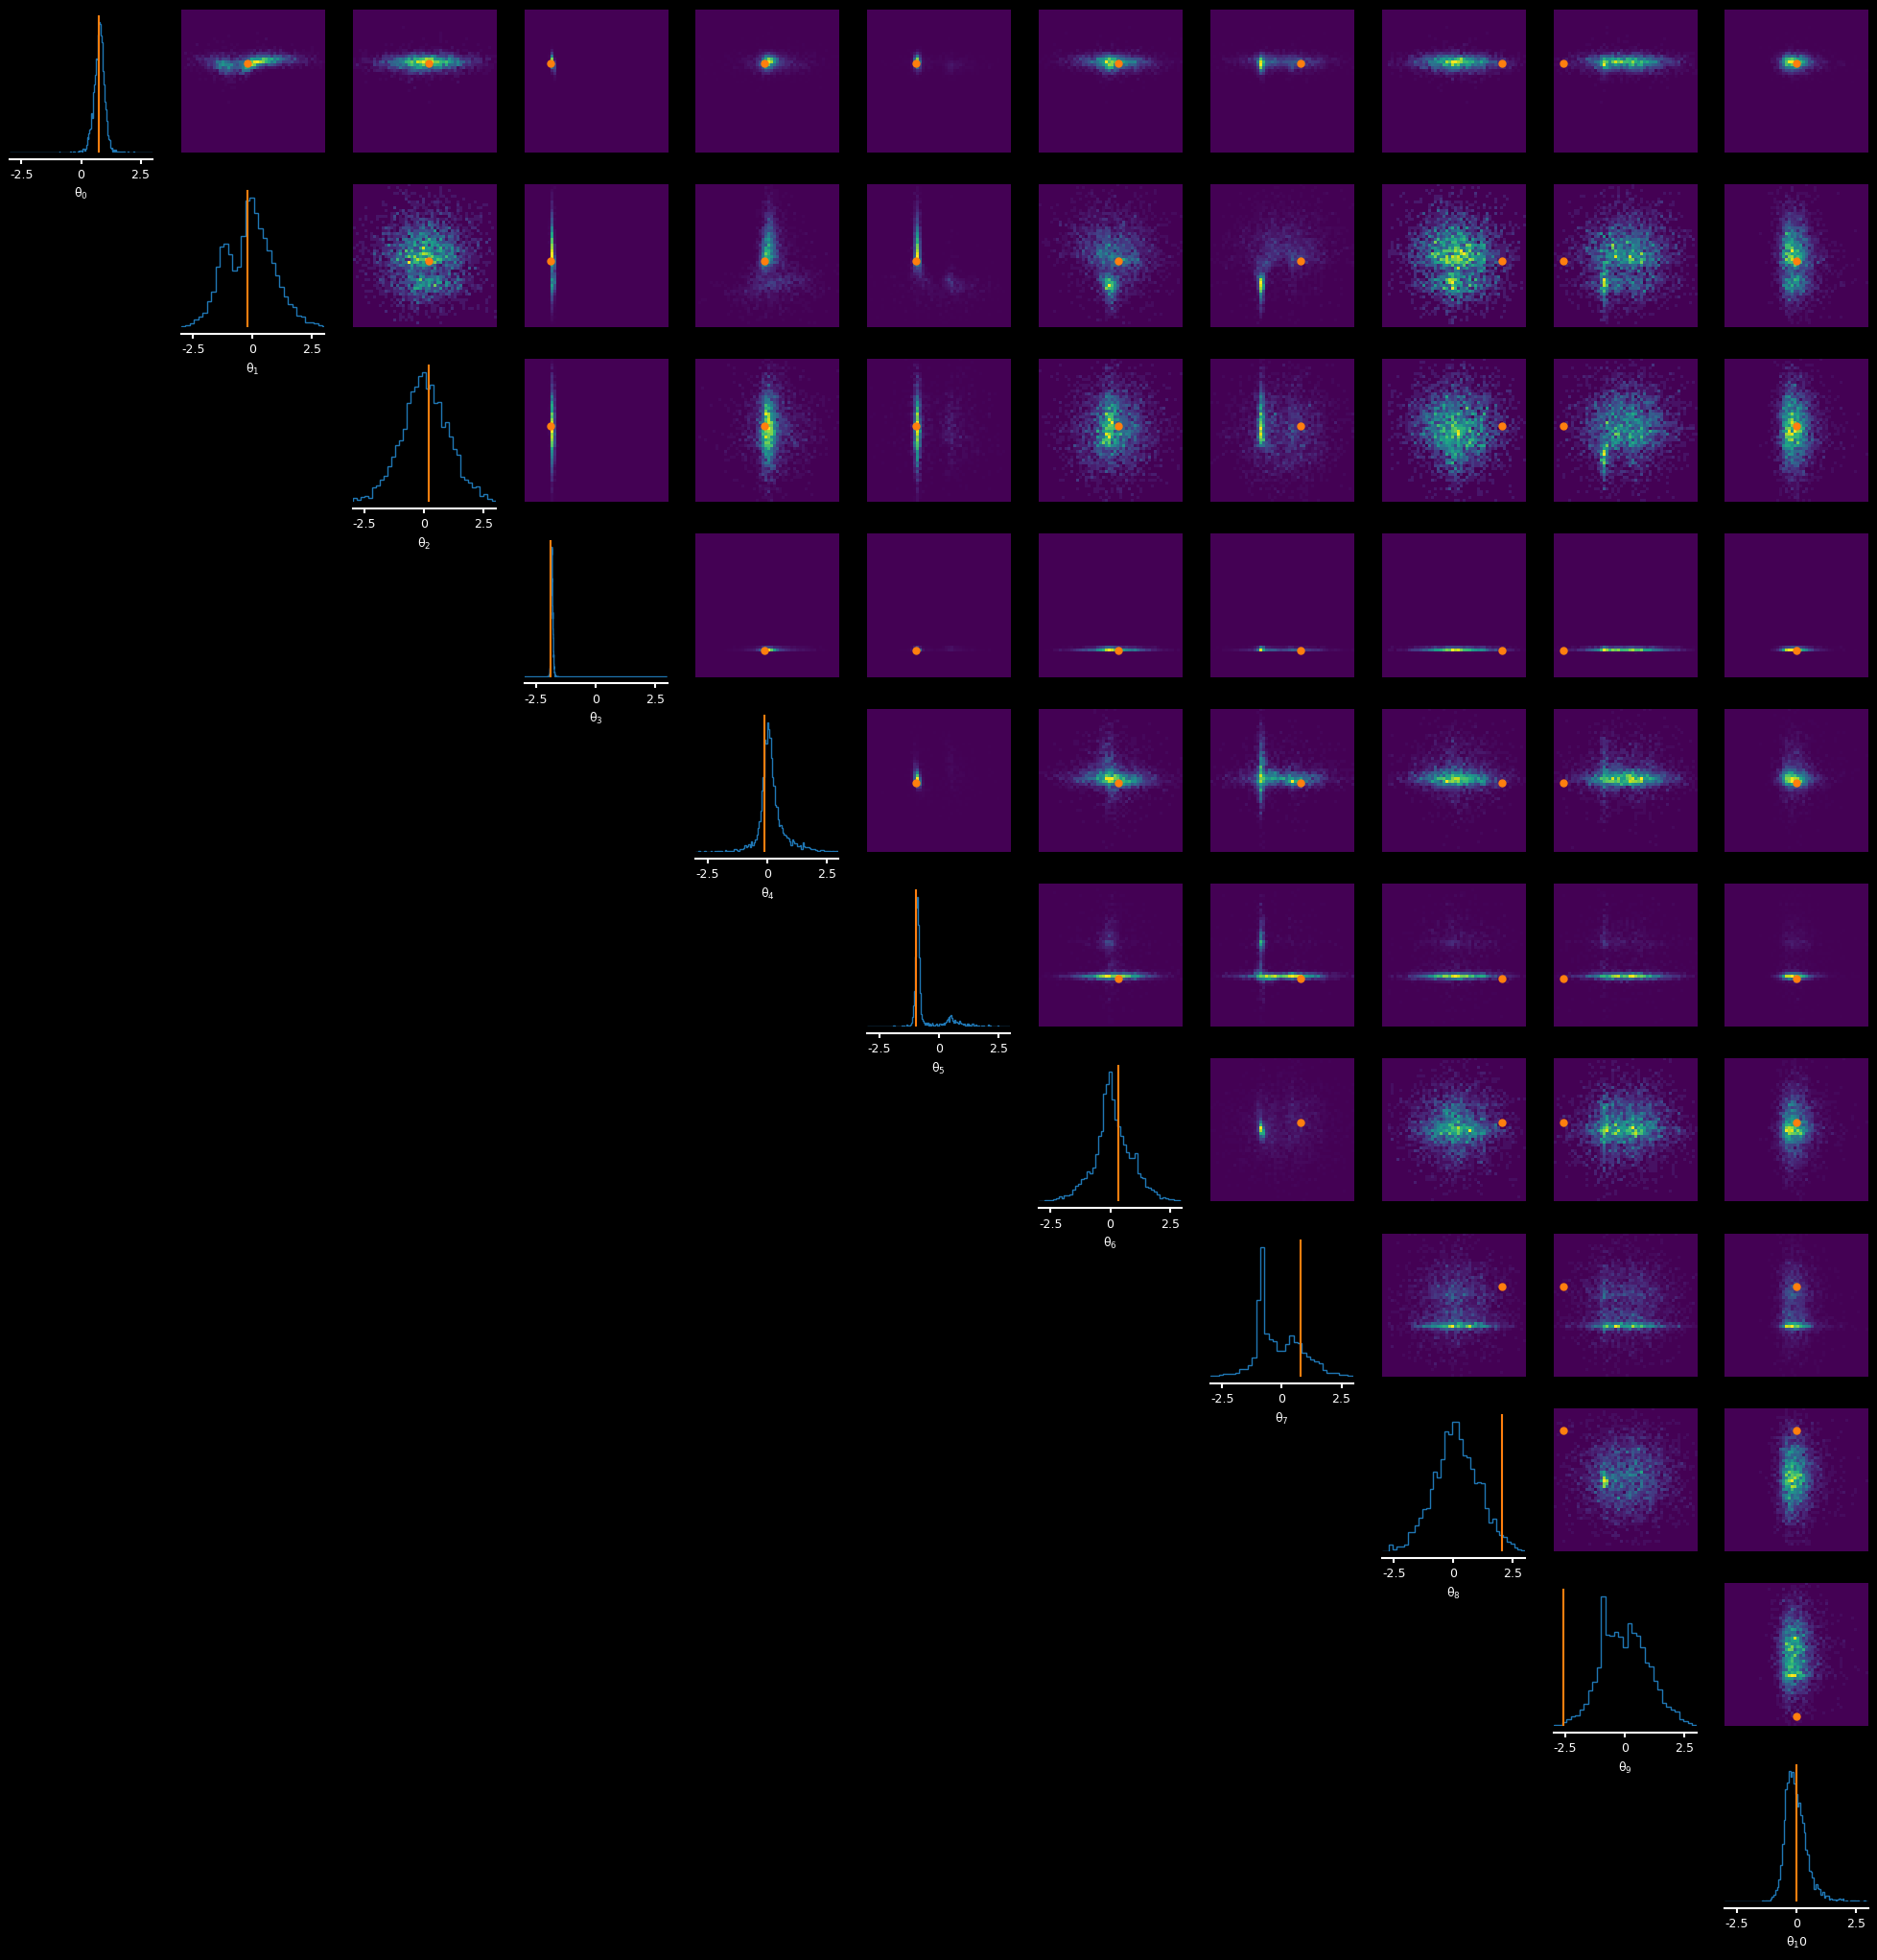

In [ ]:
import sbi
from sbi.analysis.plot import pairplot

_ = pairplot(thetas_post, points=[thetas[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

In [49]:
def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=masks[idx]).signal(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), rng=rng)

def loglikelihood(theta):
    simulator = sim_type.from_theta(theta, model_mask=masks[idx])
    ll = simulator.log_likelihood(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x_os[idx])
    return ll

posterior_preds = jax.vmap(posterior_pred)(thetas_post, jax.random.split(jax.random.key(0), 4096))

Text(0, 0.5, 'MRI Signal')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

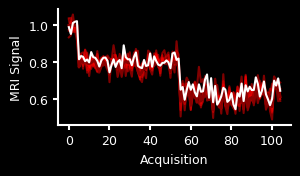

In [50]:
bvals = acq.bvals[idx]
bvecs = acq.bvecs[idx]
sort_bvals = jnp.argsort(bvals)
bvals = bvals[sort_bvals]
posterior_preds_sorted = posterior_preds[:,sort_bvals]
x_o = x_os[idx][sort_bvals]


fig = plt.figure(figsize=(3, 1.5))

_ = plt.plot(posterior_preds_sorted[:5].T, label="posterior pred", color="red", alpha=0.5)
_ = plt.plot(posterior_preds_sorted.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_o, label="data", color="white")
plt.xlabel("Acquisition")
plt.ylabel("MRI Signal")

# fig.savefig(f"../figures/posterior_pred_idx={idx}.svg")
# fig.savefig(f"../figures/posterior_pred_idx={idx}.png")

In [39]:
def loglikelihood(theta, mask, acq, x):
    simulator = sim_type.from_theta(theta, model_mask=mask)
    ll = simulator.log_likelihood(acq, x)
    return ll

def log_posterior(theta, mask, acq, x):
    theta_mask = model.tokenizer.theta_mask(mask)
    return loglikelihood(theta, mask, acq, x) + (theta_mask*jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)).sum()

def log_q(theta, mask, acq, x):
    return model.log_prob_theta(theta, acq.bvals, acq.bvecs, x, num_steps=512, max_noise=80, model_mask=mask)

@jax.grad
def true_score(theta, mask, acq, x):
    return log_posterior(theta, mask, acq, x).sum()


@jax.jit
def effectve_sample_size(thetas):
    logp = jax.vmap(partial(log_posterior, mask=masks[idx], acq=acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x=x_os[idx]))(thetas)
    logq = jax.vmap(partial(log_q, mask=masks[idx], acq=acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x=x_os[idx]))(thetas)
    log_w = logp - logq
    # Self normalized importance weights
    w = jax.nn.softmax(log_w)
    return 1/jnp.sum(w**2)


In [40]:
effectve_sample_size(thetas_post)

(0, 1, 2, 3, 4)


Array(12.79, dtype=float32)